In [1]:
# !pip install 'zarr<3'
# !pip install timm


In [2]:
# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"✅ Working directory: {os.getcwd()}")

✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest


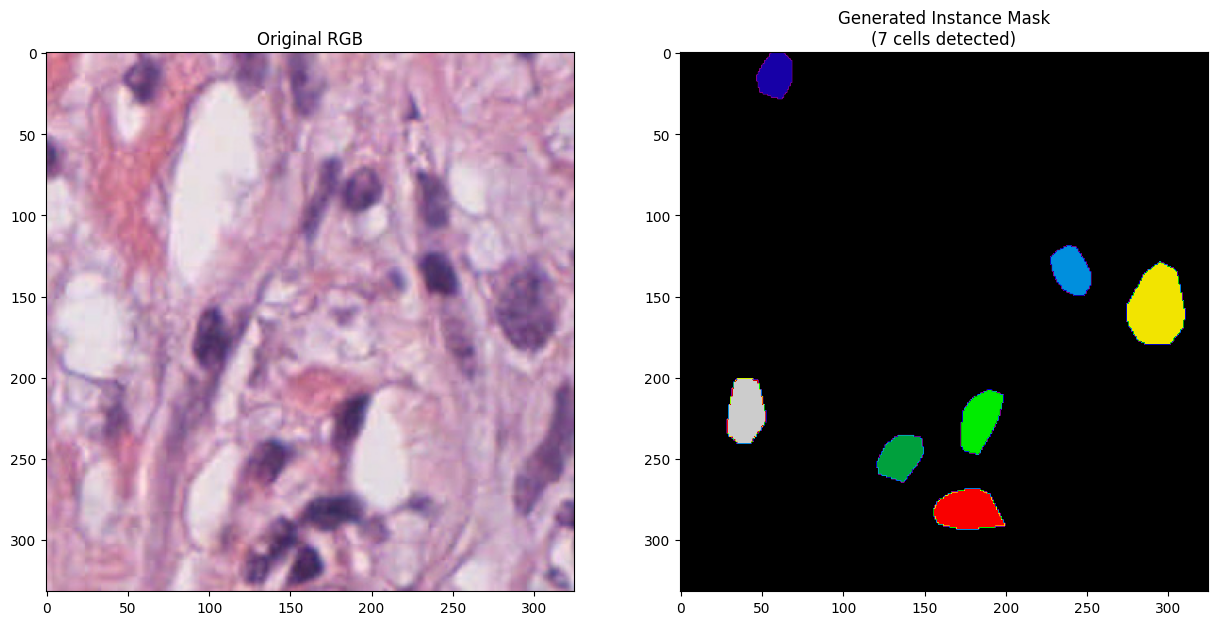

In [9]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIGURATION ---
BASE_PATH = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER1/yasin-vitaminp/public-datasets/NuCLS")
IMG_DIR = BASE_PATH / "rgb"
CSV_DIR = BASE_PATH / "csv"

# Using the filename from your screenshot
sample_stem = "TCGA-A1-A0SP-DX1_id-5ea4095addda5f8398977ebc_left-7053_top-53967_bottom-54231_right-7311"
img_path = IMG_DIR / f"{sample_stem}.png"
csv_path = CSV_DIR / f"{sample_stem}.csv"

def generate_instance_from_csv(img_path, csv_path):
    # 1. Load Image to get dimensions
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]
    
    # 2. Load CSV
    df = pd.read_csv(csv_path)
    
    # Create empty mask (int32 to support many instances)
    instance_mask = np.zeros((h, w), dtype=np.int32)
    
    # 3. Filter for 'polyline' to get actual cell boundaries (polygons)
    # If you also want rectangles, you can remove this filter
    polygons = df[df['type'] == 'polyline']
    
    for i, (_, row) in enumerate(polygons.iterrows(), start=1):
        # Parse coordinate strings
        try:
            x_coords = [int(float(x)) for x in str(row['coords_x']).split(',')]
            y_coords = [int(float(y)) for y in str(row['coords_y']).split(',')]
            
            # Create vertex array: [[x1, y1], [x2, y2], ...]
            pts = np.array([[[x, y] for x, y in zip(x_coords, y_coords)]], dtype=np.int32)
            
            # Draw the filled polygon with a unique ID
            cv2.fillPoly(instance_mask, pts, i)
        except Exception as e:
            print(f"Skipping row {i} due to error: {e}")
            
    return img, instance_mask

# --- RUN AND VISUALIZE ---
image, mask = generate_instance_from_csv(img_path, csv_path)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original RGB")
axes[1].imshow(mask, cmap='nipy_spectral') # High contrast for instances
axes[1].set_title(f"Generated Instance Mask\n({np.max(mask)} cells detected)")
plt.show()

In [4]:
import os
import glob
import numpy as np
import zarr
import pandas as pd
import cv2
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

# ---------------------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------------------
BASE_PATH = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER1/yasin-vitaminp/public-datasets/NuCLS")
IMG_DIR = BASE_PATH / "rgb"
MASK_DIR = BASE_PATH / "mask"

# Output Path
OUTPUT_BASE_PATH = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/nucls/zarr_data")

PATCH_SIZE = 512
NUM_WORKERS = 32 # NuCLS images are often larger; 32 is safer for RAM

# ---------------------------------------------------------------------
# 2. Helper Functions
# ---------------------------------------------------------------------
def get_smart_coords(length, crop_size):
    if length <= crop_size:
        return [0]
    coords = list(range(0, length - crop_size, crop_size))
    coords.append(length - crop_size)
    return sorted(list(set(coords)))

def process_and_stack_nucls(args):
    img_path, mask_path, file_name, out_dir = args
    
    try:
        # --- A. Load & Decode ---
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        raw_mask = cv2.imread(str(mask_path))
        
        # Robust Shape Match: Resize mask to match image if they differ by a few pixels
        if img.shape[:2] != raw_mask.shape[:2]:
            raw_mask = cv2.resize(raw_mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

        # Decode Instance ID: InstanceID = Green * 256 + Blue
        inst_map = raw_mask[:,:,1].astype(np.int32) * 256 + raw_mask[:,:,2].astype(np.int32)
        
        h, w = img.shape[:2]
        
        # Pad if smaller than 512
        pad_h = max(0, PATCH_SIZE - h)
        pad_w = max(0, PATCH_SIZE - w)
        if pad_h > 0 or pad_w > 0:
            img = np.pad(img, ((0, pad_h), (0, pad_w), (0, 0)), constant_values=0)
            inst_map = np.pad(inst_map, ((0, pad_h), (0, pad_w)), constant_values=0)
            h, w = img.shape[:2]

        # --- B. Generate All Crops ---
        y_points = get_smart_coords(h, PATCH_SIZE)
        x_points = get_smart_coords(w, PATCH_SIZE)
        
        img_stack, nuc_stack, metadata_list = [], [], []
        
        for y in y_points:
            for x in x_points:
                crop_img = img[y : y+PATCH_SIZE, x : x+PATCH_SIZE]
                crop_nuc = inst_map[y : y+PATCH_SIZE, x : x+PATCH_SIZE]
                
                if crop_img.shape == (PATCH_SIZE, PATCH_SIZE, 3):
                    img_stack.append(crop_img)
                    nuc_stack.append(crop_nuc)
                    metadata_list.append({'original_file': file_name, 'x': x, 'y': y})

        # --- C. Stack & Save ---
        final_imgs = np.stack(img_stack, axis=0)
        final_nucs = np.stack(nuc_stack, axis=0)
        
        slide_out_path = out_dir / file_name
        slide_out_path.mkdir(parents=True, exist_ok=True)
        
        # Save Images
        z_img = zarr.open(slide_out_path / 'images.zarr', mode='w', shape=final_imgs.shape,
                          chunks=(1, PATCH_SIZE, PATCH_SIZE, 3), dtype='uint8',
                          compressor=zarr.Blosc(cname='zstd', clevel=3))
        z_img[:] = final_imgs
        
        # Save Masks
        z_nuc = zarr.open(slide_out_path / 'nuclei_masks.zarr', mode='w', shape=final_nucs.shape,
                          chunks=(1, PATCH_SIZE, PATCH_SIZE), dtype='int32',
                          compressor=zarr.Blosc(cname='zstd', clevel=3))
        z_nuc[:] = final_nucs
        
        pd.DataFrame(metadata_list).to_csv(slide_out_path / 'metadata.csv', index=False)
        return final_imgs.shape[0]

    except Exception as e:
        print(f"Error {file_name}: {e}")
        return 0

# ---------------------------------------------------------------------
# 3. Execution
# ---------------------------------------------------------------------
if __name__ == "__main__":
    print(f"🧬 NuCLS STACKED CONVERSION (Zarr Format)")
    all_images = sorted(list(IMG_DIR.glob("*.png")))
    OUTPUT_BASE_PATH.mkdir(parents=True, exist_ok=True)
    
    tasks = []
    for img_p in all_images:
        fname = img_p.name
        mask_p = MASK_DIR / fname
        if mask_p.exists():
            tasks.append((img_p, mask_p, img_p.stem, OUTPUT_BASE_PATH))
            
    print(f"Processing {len(tasks)} slides...")
    with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
        results = list(tqdm(executor.map(process_and_stack_nucls, tasks), total=len(tasks)))
        
    print(f"Done! Created {sum(results)} patches across {len(tasks)} slides.")

🧬 NuCLS STACKED CONVERSION (Zarr Format)
Processing 1744 slides...


100%|██████████| 1744/1744 [00:31<00:00, 54.68it/s]

Done! Created 1889 patches across 1744 slides.


🔎 Verifying NuCLS Zarr Sample: TCGA-A1-A0SP-DX1_id-5ea4095addda5f8398977ebc_left-11868_top-53956_bottom-54243_right-12182

📊 DATASET STATS
  Image Stack Shape: (1, 512, 512, 3) (N, H, W, C)
  Mask Stack Shape:  (1, 512, 512) (N, H, W)
  Dtypes:            Img: uint8 | Mask: int32
  Metadata Found:    True
✅ Patch 0 verification:
   Max Instance ID: 509
   Unique Nuclei:   3


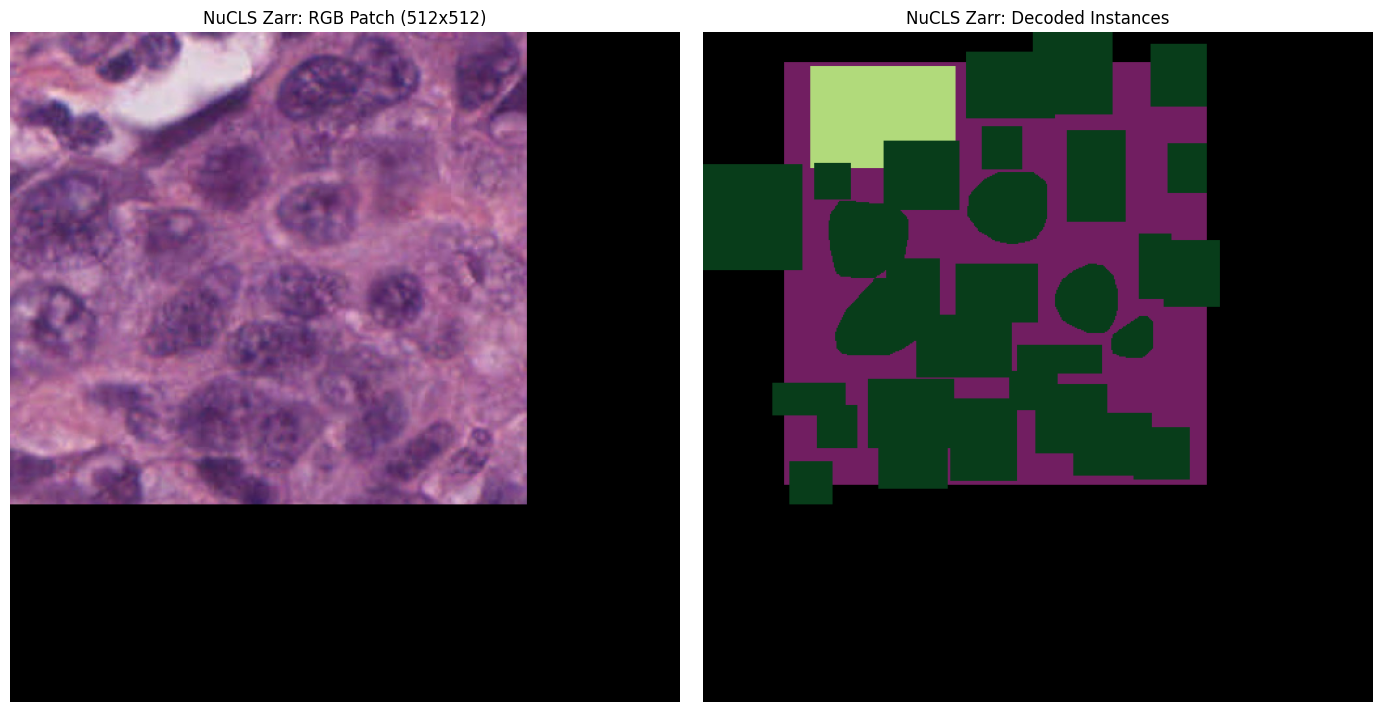

In [7]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# ---------------------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------------------
nucls_zarr_path = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/nucls/zarr_data")

# Find a sample slide directory
if nucls_zarr_path.exists():
    samples = sorted([d for d in os.listdir(nucls_zarr_path) 
                      if os.path.isdir(nucls_zarr_path / d)])
    # Pick a sample (e.g., the 5th one or the last one if fewer than 5)
    sample_name = samples[min(4, len(samples)-1)]
    sample_path = nucls_zarr_path / sample_name
    print(f"🔎 Verifying NuCLS Zarr Sample: {sample_name}")
else:
    print(f"❌ Path not found: {nucls_zarr_path}")
    sample_path = None

# ---------------------------------------------------------------------
# 2. Decoding & Integrity Check
# ---------------------------------------------------------------------
def verify_nucls_stack(path):
    if not path: return
    
    try:
        # Load Zarr Arrays
        z_img = zarr.open(str(path / 'images.zarr'), mode='r')
        z_nuc = zarr.open(str(path / 'nuclei_masks.zarr'), mode='r')
        
        # Load Metadata for coordinate verification
        metadata = os.path.join(path, 'metadata.csv')
        has_meta = os.path.exists(metadata)
        
        print("\n" + "="*50)
        print(f"📊 DATASET STATS")
        print(f"  Image Stack Shape: {z_img.shape} (N, H, W, C)")
        print(f"  Mask Stack Shape:  {z_nuc.shape} (N, H, W)")
        print(f"  Dtypes:            Img: {z_img.dtype} | Mask: {z_nuc.dtype}")
        print(f"  Metadata Found:    {has_meta}")
        print("="*50)

        # Grab the first patch
        patch_idx = 0
        img_patch = z_img[patch_idx]
        nuc_patch = z_nuc[patch_idx]
        
        # Instance Check
        unique_ids = np.unique(nuc_patch)
        print(f"✅ Patch {patch_idx} verification:")
        print(f"   Max Instance ID: {nuc_patch.max()}")
        print(f"   Unique Nuclei:   {len(unique_ids) - 1 if 0 in unique_ids else len(unique_ids)}")

        return img_patch, nuc_patch

    except Exception as e:
        print(f"❌ Error during verification: {e}")
        return None, None

# ---------------------------------------------------------------------
# 3. Visualization
# ---------------------------------------------------------------------
def colorize(mask):
    """Assigns random colors to instance IDs for visual check."""
    max_id = int(mask.max())
    if max_id == 0: return np.zeros((*mask.shape, 3))
    colors = np.random.rand(max_id + 1, 3)
    colors[0] = [0, 0, 0] # Background = Black
    return colors[mask]

img_sample, nuc_sample = verify_nucls_stack(sample_path)

if img_sample is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    # Show RGB
    axes[0].imshow(img_sample)
    axes[0].set_title("NuCLS Zarr: RGB Patch (512x512)")
    axes[0].axis('off')
    
    # Show Instances
    axes[1].imshow(colorize(nuc_sample))
    axes[1].set_title("NuCLS Zarr: Decoded Instances")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()